<a href="https://colab.research.google.com/github/harald-gen01/My_AI_learning_path/blob/main/Prompt_Caching_Demo_(Simple).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prompt Caching Demo (Simple): Repeated Prefixes, Latency, and Tradeoffs

This notebook demonstrates the *concept* of prompt caching in a simple, educational way.

## What this notebook shows
- Why repeated prompt prefixes can improve performance
- Why **static-first / dynamic-last** prompt design matters
- How cache hits, misses, and TTL expiration affect outcomes
- A simple break-even view (when caching starts to pay off)

## What this notebook does NOT prove
- Exact savings for any specific provider or model
- Universal latency behavior (provider/model/endpoints differ)
- Production-grade caching implementation details

We start with a simulation (no API key needed), then include an optional real API test section.

**Imports**

In [1]:
import time
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple

import pandas as pd
import matplotlib.pyplot as plt

**Build a Fake “Enterprise Prompt Scaffold”**


In [2]:
# ----------------------------
# 1) Create a long static prefix
# ----------------------------

SYSTEM_INSTRUCTIONS = """
You are an enterprise support assistant.
Follow policy exactly.
Be concise, accurate, and professional.
Do not invent unsupported claims.
If policy is unclear, state uncertainty and recommend escalation.
"""

POLICY_BLOCK = """
Support Policy (v3.2)
- Warranty claims require proof of purchase.
- Returns are accepted within 30 days unless marked final sale.
- Safety incidents must be escalated immediately.
- Installation guidance must include safety warnings.
- Regional restrictions may apply depending on country and product line.
"""

TOOL_DEFINITIONS = """
Available tools:
1) lookup_manual(section_id)
2) lookup_policy(policy_id)
3) create_escalation_ticket(category, severity, summary)
Tool usage rules:
- Use tools only when needed.
- Explain final answer in plain English.
"""

# Create a long "manual" by repeating content (simulates a large context window payload)
MANUAL_SECTION = """
Product Manual Excerpt:
Installation requires grounded outlet verification.
Do not expose unit to rain or excessive humidity.
For reset procedure, hold the power and mode buttons for 10 seconds.
Warranty excludes unauthorized modifications and physical abuse.
Return policy details vary by region and purchase channel.
"""

LONG_MANUAL = (MANUAL_SECTION * 120).strip()  # intentionally long for the demo

STATIC_PREFIX = f"""
{SYSTEM_INSTRUCTIONS}

{POLICY_BLOCK}

{TOOL_DEFINITIONS}

Reference Manual:
{LONG_MANUAL}
""".strip()

questions = [
    "What are the warranty terms for accidental damage?",
    "What is the return policy window?",
    "How do I reset the device?",
    "What are the installation safety warnings?",
    "When should support escalate a safety incident?",
    "Are regional restrictions mentioned?",
    "Does warranty require proof of purchase?",
    "What happens if the device was modified?",
    "Can returns be denied after 30 days?",
    "What should a support agent say if policy is unclear?",
    "Is rain exposure mentioned in the manual?",
    "What tools are available to the assistant?",
]

print(f"Static prefix length (chars): {len(STATIC_PREFIX):,}")
print(f"Approx token proxy (chars/4): {len(STATIC_PREFIX)//4:,}")
print(f"Questions: {len(questions)}")

Static prefix length (chars): 39,156
Approx token proxy (chars/4): 9,789
Questions: 12


**Helper Functions (Simulation Engine)**

In [3]:
# ----------------------------
# 2) Simulation engine
# ----------------------------

def token_proxy(text: str) -> int:
    """
    Rough token estimate for educational purposes only.
    """
    return max(1, len(text) // 4)


@dataclass
class SimConfig:
    # "Latency" parameters (fake but useful for demonstration)
    base_latency_ms: float = 120.0
    ms_per_prefill_token: float = 0.08
    ms_per_generation_token: float = 0.03
    generation_tokens: int = 180

    # "Cost" parameters in relative units (not dollars)
    input_cost_per_token: float = 1.0
    cache_read_multiplier: float = 0.15   # cheaper than full input processing
    cache_write_multiplier: float = 1.25  # writing cache may cost overhead

    # Cache behavior
    ttl_seconds: float = 10.0  # short TTL for demonstration
    jitter_ms: float = 15.0    # to make charts look realistic


class PromptCacheSimulator:
    def __init__(self, config: SimConfig):
        self.config = config
        self.cache: Dict[str, Dict] = {}

    def _prefix_key(self, prefix: str) -> str:
        # Exact match for simulation
        return prefix

    def _is_valid(self, key: str, now_ts: float) -> bool:
        entry = self.cache.get(key)
        if not entry:
            return False
        return now_ts <= entry["expires_at"]

    def run_request(self, prefix: str, suffix_question: str, now_ts: float) -> Dict:
        cfg = self.config

        prefix_tokens = token_proxy(prefix)
        suffix_tokens = token_proxy(suffix_question)
        gen_tokens = cfg.generation_tokens

        key = self._prefix_key(prefix)
        hit = self._is_valid(key, now_ts)

        # Prefill tokens processed:
        # - hit: only suffix needs prefill
        # - miss: prefix + suffix need prefill
        if hit:
            prefill_tokens_processed = suffix_tokens
            cache_read_tokens = prefix_tokens
            cache_write_tokens = 0

            input_cost_units = (
                suffix_tokens * cfg.input_cost_per_token
                + cache_read_tokens * cfg.input_cost_per_token * cfg.cache_read_multiplier
            )
        else:
            prefill_tokens_processed = prefix_tokens + suffix_tokens
            cache_read_tokens = 0
            cache_write_tokens = prefix_tokens  # assume prefix gets written

            input_cost_units = (
                (prefix_tokens + suffix_tokens) * cfg.input_cost_per_token
                + cache_write_tokens * cfg.input_cost_per_token * (cfg.cache_write_multiplier - 1.0)
            )

            # Write/update cache
            self.cache[key] = {
                "expires_at": now_ts + cfg.ttl_seconds,
                "prefix_tokens": prefix_tokens,
            }

        latency_ms = (
            cfg.base_latency_ms
            + prefill_tokens_processed * cfg.ms_per_prefill_token
            + gen_tokens * cfg.ms_per_generation_token
            + random.uniform(-cfg.jitter_ms, cfg.jitter_ms)
        )

        # Refresh TTL on hit (common behavior in many systems)
        if hit:
            self.cache[key]["expires_at"] = now_ts + cfg.ttl_seconds

        return {
            "hit": hit,
            "prefix_tokens": prefix_tokens,
            "suffix_tokens": suffix_tokens,
            "prefill_tokens_processed": prefill_tokens_processed,
            "cache_read_tokens": cache_read_tokens,
            "cache_write_tokens": cache_write_tokens,
            "latency_ms": max(1, latency_ms),
            "input_cost_units": input_cost_units,
            "total_prompt_tokens_proxy": prefix_tokens + suffix_tokens,
        }

**Run Scenario A (Good Layout: Static First, Dynamic Last)**

In [4]:
# ----------------------------
# 3) Scenario A: GOOD layout (static first, dynamic last)
# ----------------------------

cfg = SimConfig(ttl_seconds=10.0)
sim_good = PromptCacheSimulator(cfg)

records_good = []
start_ts = time.time()

for i, q in enumerate(questions, start=1):
    now_ts = start_ts + i * 1.0  # requests arrive 1 second apart (within TTL)
    result = sim_good.run_request(prefix=STATIC_PREFIX, suffix_question=q, now_ts=now_ts)
    records_good.append({
        "request_id": i,
        "scenario": "good_layout_same_prefix",
        "question": q,
        **result
    })

df_good = pd.DataFrame(records_good)
df_good

,request_id,scenario,question,hit,prefix_tokens,suffix_tokens,prefill_tokens_processed,cache_read_tokens,cache_write_tokens,latency_ms,input_cost_units,total_prompt_tokens_proxy
0,1,good_layout_same_prefix,What are the warranty terms for accidental dam...,False,9789,12,9801,0,9789,901.354055,12248.25,9801
1,2,good_layout_same_prefix,What is the return policy window?,True,9789,8,8,9789,0,121.293864,1476.35,9797
2,3,good_layout_same_prefix,How do I reset the device?,True,9789,6,6,9789,0,137.548912,1474.35,9795
3,4,good_layout_same_prefix,What are the installation safety warnings?,True,9789,10,10,9789,0,115.619459,1478.35,9799
4,5,good_layout_same_prefix,When should support escalate a safety incident?,True,9789,11,11,9789,0,137.603959,1479.35,9800
5,6,good_layout_same_prefix,Are regional restrictions mentioned?,True,9789,9,9,9789,0,135.683117,1477.35,9798
6,7,good_layout_same_prefix,Does warranty require proof of purchase?,True,9789,10,10,9789,0,137.167251,1478.35,9799
7,8,good_layout_same_prefix,What happens if the device was modified?,True,9789,10,10,9789,0,130.719062,1478.35,9799
8,9,good_layout_same_prefix,Can returns be denied after 30 days?,True,9789,9,9,9789,0,120.949074,1477.35,9798
9,10,good_layout_same_prefix,What should a support agent say if policy is u...,True,9789,13,13,9789,0,115.557339,1481.35,9802


**Run Scenario B (Bad Layout: Dynamic First Breaks Prefix Reuse)**

In [5]:
# ----------------------------
# 4) Scenario B: BAD layout (dynamic first)
# Here, the changing question is placed first, so the prefix changes each time.
# ----------------------------

sim_bad = PromptCacheSimulator(cfg)

records_bad = []
start_ts = time.time()

for i, q in enumerate(questions, start=1):
    # Bad structure: question first, then static content
    bad_prefix = f"User question: {q}\n\n{STATIC_PREFIX}"  # changing prefix every time
    now_ts = start_ts + i * 1.0
    result = sim_bad.run_request(prefix=bad_prefix, suffix_question="", now_ts=now_ts)
    records_bad.append({
        "request_id": i,
        "scenario": "bad_layout_dynamic_first",
        "question": q,
        **result
    })

df_bad = pd.DataFrame(records_bad)
df_bad

,request_id,scenario,question,hit,prefix_tokens,suffix_tokens,prefill_tokens_processed,cache_read_tokens,cache_write_tokens,latency_ms,input_cost_units,total_prompt_tokens_proxy
0,1,bad_layout_dynamic_first,What are the warranty terms for accidental dam...,False,9805,1,9806,0,9805,905.971678,12257.25,9806
1,2,bad_layout_dynamic_first,What is the return policy window?,False,9801,1,9802,0,9801,897.103643,12252.25,9802
2,3,bad_layout_dynamic_first,How do I reset the device?,False,9799,1,9800,0,9799,919.536150,12249.75,9800
3,4,bad_layout_dynamic_first,What are the installation safety warnings?,False,9803,1,9804,0,9803,911.739694,12254.75,9804
4,5,bad_layout_dynamic_first,When should support escalate a safety incident?,False,9805,1,9806,0,9805,910.761129,12257.25,9806
5,6,bad_layout_dynamic_first,Are regional restrictions mentioned?,False,9802,1,9803,0,9802,895.575474,12253.50,9803
6,7,bad_layout_dynamic_first,Does warranty require proof of purchase?,False,9803,1,9804,0,9803,920.896974,12254.75,9804
7,8,bad_layout_dynamic_first,What happens if the device was modified?,False,9803,1,9804,0,9803,917.904710,12254.75,9804
8,9,bad_layout_dynamic_first,Can returns be denied after 30 days?,False,9802,1,9803,0,9802,920.472508,12253.50,9803
9,10,bad_layout_dynamic_first,What should a support agent say if policy is u...,False,9806,1,9807,0,9806,912.159731,12258.50,9807


**Run Scenario C (Tiny Prefix Change Causes Misses)**

In [6]:
# ----------------------------
# 5) Scenario C: Tiny prefix change (version stamp / timestamp / random string)
# Demonstrates how small changes can break exact prefix matching.
# ----------------------------

sim_tiny_change = PromptCacheSimulator(cfg)

records_tiny = []
start_ts = time.time()

for i, q in enumerate(questions, start=1):
    # Tiny prefix difference each request (bad for exact prefix caching)
    prefix_with_noise = STATIC_PREFIX + f"\nRequest-Metadata: trace_id={i}"
    now_ts = start_ts + i * 1.0
    result = sim_tiny_change.run_request(prefix=prefix_with_noise, suffix_question=q, now_ts=now_ts)
    records_tiny.append({
        "request_id": i,
        "scenario": "tiny_prefix_change_each_request",
        "question": q,
        **result
    })

df_tiny = pd.DataFrame(records_tiny)
df_tiny

,request_id,scenario,question,hit,prefix_tokens,suffix_tokens,prefill_tokens_processed,cache_read_tokens,cache_write_tokens,latency_ms,input_cost_units,total_prompt_tokens_proxy
0,1,tiny_prefix_change_each_request,What are the warranty terms for accidental dam...,False,9796,12,9808,0,9796,898.962980,12257.0,9808
1,2,tiny_prefix_change_each_request,What is the return policy window?,False,9796,8,9804,0,9796,903.749587,12253.0,9804
2,3,tiny_prefix_change_each_request,How do I reset the device?,False,9796,6,9802,0,9796,920.199372,12251.0,9802
3,4,tiny_prefix_change_each_request,What are the installation safety warnings?,False,9796,10,9806,0,9796,920.989202,12255.0,9806
4,5,tiny_prefix_change_each_request,When should support escalate a safety incident?,False,9796,11,9807,0,9796,909.902979,12256.0,9807
5,6,tiny_prefix_change_each_request,Are regional restrictions mentioned?,False,9796,9,9805,0,9796,909.473244,12254.0,9805
6,7,tiny_prefix_change_each_request,Does warranty require proof of purchase?,False,9796,10,9806,0,9796,912.222031,12255.0,9806
7,8,tiny_prefix_change_each_request,What happens if the device was modified?,False,9796,10,9806,0,9796,902.976772,12255.0,9806
8,9,tiny_prefix_change_each_request,Can returns be denied after 30 days?,False,9796,9,9805,0,9796,906.294168,12254.0,9805
9,10,tiny_prefix_change_each_request,What should a support agent say if policy is u...,False,9796,13,9809,0,9796,900.030392,12258.0,9809


**Run Scenario D (TTL Expiry)**

In [7]:
# ----------------------------
# 6) Scenario D: TTL expiry
# Requests are spaced out enough to expire cache between calls.
# ----------------------------

sim_ttl = PromptCacheSimulator(cfg)

records_ttl = []
start_ts = time.time()

for i, q in enumerate(questions, start=1):
    now_ts = start_ts + i * 12.0  # 12 seconds apart, TTL is 10s -> frequent missesm, you could change as you like, play around
    result = sim_ttl.run_request(prefix=STATIC_PREFIX, suffix_question=q, now_ts=now_ts)
    records_ttl.append({
        "request_id": i,
        "scenario": "ttl_expiry",
        "question": q,
        **result
    })

df_ttl = pd.DataFrame(records_ttl)
df_ttl

,request_id,scenario,question,hit,prefix_tokens,suffix_tokens,prefill_tokens_processed,cache_read_tokens,cache_write_tokens,latency_ms,input_cost_units,total_prompt_tokens_proxy
0,1,ttl_expiry,What are the warranty terms for accidental dam...,False,9789,12,9801,0,9789,898.178567,12248.25,9801
1,2,ttl_expiry,What is the return policy window?,False,9789,8,9797,0,9789,919.499320,12244.25,9797
2,3,ttl_expiry,How do I reset the device?,False,9789,6,9795,0,9789,909.816432,12242.25,9795
3,4,ttl_expiry,What are the installation safety warnings?,False,9789,10,9799,0,9789,924.204212,12246.25,9799
4,5,ttl_expiry,When should support escalate a safety incident?,False,9789,11,9800,0,9789,924.028502,12247.25,9800
5,6,ttl_expiry,Are regional restrictions mentioned?,False,9789,9,9798,0,9789,904.106927,12245.25,9798
6,7,ttl_expiry,Does warranty require proof of purchase?,False,9789,10,9799,0,9789,921.654068,12246.25,9799
7,8,ttl_expiry,What happens if the device was modified?,False,9789,10,9799,0,9789,904.171654,12246.25,9799
8,9,ttl_expiry,Can returns be denied after 30 days?,False,9789,9,9798,0,9789,905.979195,12245.25,9798
9,10,ttl_expiry,What should a support agent say if policy is u...,False,9789,13,9802,0,9789,896.324531,12249.25,9802


**Combine Results + Summary Table**

In [8]:
# ----------------------------
# 7) Combine and summarize
# ----------------------------

df_all = pd.concat([df_good, df_bad, df_tiny, df_ttl], ignore_index=True)

summary = (
    df_all.groupby("scenario")
    .agg(
        requests=("request_id", "count"),
        cache_hits=("hit", "sum"),
        hit_rate=("hit", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
        p95_latency_ms=("latency_ms", lambda s: s.quantile(0.95)),
        total_cost_units=("input_cost_units", "sum"),
        avg_cost_units=("input_cost_units", "mean"),
        total_cache_read_tokens=("cache_read_tokens", "sum"),
        total_cache_write_tokens=("cache_write_tokens", "sum"),
    )
    .reset_index()
)

summary["hit_rate"] = (summary["hit_rate"] * 100).round(1)
summary = summary.sort_values("scenario").reset_index(drop=True)
summary

,scenario,requests,cache_hits,hit_rate,avg_latency_ms,p95_latency_ms,total_cost_units,avg_cost_units,total_cache_read_tokens,total_cache_write_tokens
0,bad_layout_dynamic_first,12,0,0.0,912.261901,921.312912,147055.75,12254.645833,0,117635
1,good_layout_same_prefix,12,11,91.7,192.506256,481.291502,28506.10,2375.508333,107679,9789
2,tiny_prefix_change_each_request,12,0,0.0,907.523890,920.554796,147058.00,12254.833333,0,117552
3,ttl_expiry,12,0,0.0,910.192350,924.107572,146953.00,12246.083333,0,117468


**Business-Friendly Comparison (vs Baseline)**

In [9]:
# Treat bad_layout_dynamic_first as the baseline "no useful prompt caching" comparison
baseline_row = summary[summary["scenario"] == "bad_layout_dynamic_first"].iloc[0]

def compare_vs_baseline(row, baseline):
    latency_delta_pct = ((baseline["avg_latency_ms"] - row["avg_latency_ms"]) / baseline["avg_latency_ms"]) * 100
    cost_delta_pct = ((baseline["total_cost_units"] - row["total_cost_units"]) / baseline["total_cost_units"]) * 100
    return pd.Series({
        "avg_latency_improvement_%": round(latency_delta_pct, 1),
        "total_cost_change_%": round(cost_delta_pct, 1),
    })

comparison = summary.copy()
comparison[["avg_latency_improvement_%", "total_cost_change_%"]] = comparison.apply(
    lambda r: compare_vs_baseline(r, baseline_row), axis=1
)

comparison

,scenario,requests,cache_hits,hit_rate,avg_latency_ms,p95_latency_ms,total_cost_units,avg_cost_units,total_cache_read_tokens,total_cache_write_tokens,avg_latency_improvement_%,total_cost_change_%
0,bad_layout_dynamic_first,12,0,0.0,912.261901,921.312912,147055.75,12254.645833,0,117635,0.0,0.0
1,good_layout_same_prefix,12,11,91.7,192.506256,481.291502,28506.10,2375.508333,107679,9789,78.9,80.6
2,tiny_prefix_change_each_request,12,0,0.0,907.523890,920.554796,147058.00,12254.833333,0,117552,0.5,-0.0
3,ttl_expiry,12,0,0.0,910.192350,924.107572,146953.00,12246.083333,0,117468,0.2,0.1


**Plot: Latency Per Request (Good vs Bad)**

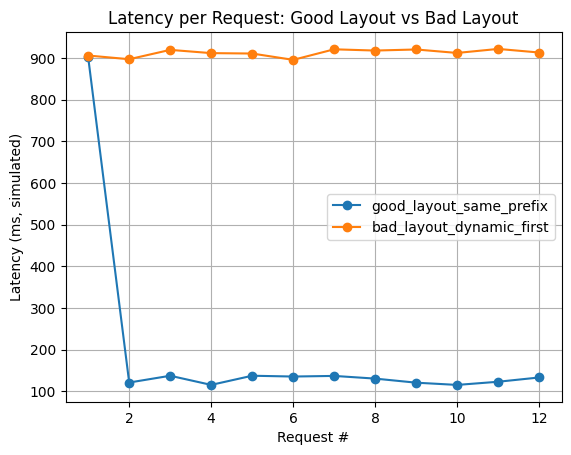

In [10]:
# ----------------------------
# 8) Visualization: latency per request
# ----------------------------

plot_df = df_all[df_all["scenario"].isin(["good_layout_same_prefix", "bad_layout_dynamic_first"])].copy()

for scenario_name in plot_df["scenario"].unique():
    subset = plot_df[plot_df["scenario"] == scenario_name]
    plt.plot(subset["request_id"], subset["latency_ms"], marker="o", label=scenario_name)

plt.title("Latency per Request: Good Layout vs Bad Layout")
plt.xlabel("Request #")
plt.ylabel("Latency (ms, simulated)")
plt.legend()
plt.grid(True)
plt.show()

**Plot: Cumulative Cost (Good vs Bad)**

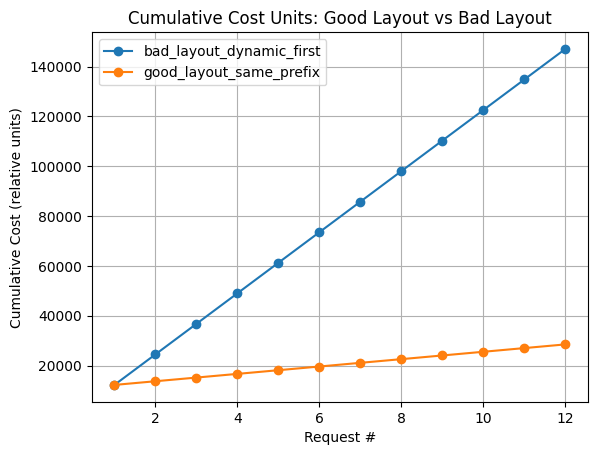

In [11]:
# ----------------------------
# 9) Visualization: cumulative cost units
# ----------------------------

compare_cost = df_all[df_all["scenario"].isin(["good_layout_same_prefix", "bad_layout_dynamic_first"])].copy()
compare_cost = compare_cost.sort_values(["scenario", "request_id"])
compare_cost["cumulative_cost_units"] = compare_cost.groupby("scenario")["input_cost_units"].cumsum()

for scenario_name in compare_cost["scenario"].unique():
    subset = compare_cost[compare_cost["scenario"] == scenario_name]
    plt.plot(subset["request_id"], subset["cumulative_cost_units"], marker="o", label=scenario_name)

plt.title("Cumulative Cost Units: Good Layout vs Bad Layout")
plt.xlabel("Request #")
plt.ylabel("Cumulative Cost (relative units)")
plt.legend()
plt.grid(True)
plt.show()

**Break-Even Request Count (Simple Estimate)**

In [12]:
# ----------------------------
# 10) Break-even estimate (good layout vs bad layout)
# ----------------------------

good = df_good.copy().sort_values("request_id")
bad = df_bad.copy().sort_values("request_id")

good["cum_cost"] = good["input_cost_units"].cumsum()
bad["cum_cost"] = bad["input_cost_units"].cumsum()

merged = good[["request_id", "cum_cost"]].merge(
    bad[["request_id", "cum_cost"]],
    on="request_id",
    suffixes=("_good", "_bad")
)

merged["good_cheaper"] = merged["cum_cost_good"] < merged["cum_cost_bad"]

break_even_candidates = merged[merged["good_cheaper"]]
if len(break_even_candidates) > 0:
    break_even_request = int(break_even_candidates["request_id"].iloc[0])
    print(f"Break-even reached at request #{break_even_request} (simulated).")
else:
    print("No break-even reached in this run (simulated).")

merged.head(12)

Break-even reached at request #1 (simulated).


,request_id,cum_cost_good,cum_cost_bad,good_cheaper
0,1,12248.25,12257.25,True
1,2,13724.60,24509.50,True
2,3,15198.95,36759.25,True
3,4,16677.30,49014.00,True
4,5,18156.65,61271.25,True
5,6,19634.00,73524.75,True
6,7,21112.35,85779.50,True
7,8,22590.70,98034.25,True
8,9,24068.05,110287.75,True
9,10,25549.40,122546.25,True


**Key Lessons**

## What this simulation demonstrates

### 1) Prompt structure matters
When the repeated content is placed first (**static-first, dynamic-last**), caching can help.
When the changing question is placed first, caching often fails immediately.

### 2) Tiny changes can break exact prefix reuse
Even a small metadata string in the prefix can reduce hit rate in exact-match caching systems.

### 3) TTL matters
If repeated requests are too far apart, cache entries may expire before the next request arrives.

### 4) Prompt caching is a performance lever, not a guarantee
Benefits depend on:
- repetition in traffic
- prompt design
- TTL behavior
- provider implementation
- governance of "static" content

**OpenAI Real API Test (Simple)**

This is intentionally light. It’s just for demonstration.
If you want, later we can make a second notebook focused on real endpoint metrics.

# Optional: Real API Test (OpenAI)

This section is optional and requires an API key.

What it does:
- Sends repeated calls with the same long prefix and different questions
- Measures wall-clock latency
- Compares with a "bad layout" version
- Prints any usage fields returned by the endpoint

Note:
- Exact prompt caching behavior depends on model, endpoint, traffic, and provider-side implementation.
- This section demonstrates measurement discipline, not guaranteed savings.

In [13]:
# Uncomment if needed in a fresh Colab runtime
# !pip -q install openai

import os
import time
from openai import OpenAI


In [26]:
from google.colab import userdata
import os

# Retrieve API key from Colab Secrets (case-sensitive key name)
OPENAI_API_KEY = userdata.get('openai_api_key')

# Optional: also set env var for consistency across cells/libraries
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

print("API key loaded from Colab userdata." if OPENAI_API_KEY else "API key not found in Colab userdata.")

client = OpenAI(api_key=OPENAI_API_KEY) if OPENAI_API_KEY else None

# Quick sanity checks
if client is not None:
    print("client type:", type(client))
    print("has responses:", hasattr(client, "responses"))
    print("client.responses type:", type(client.responses))

API key loaded from Colab userdata.
client type: <class 'openai.OpenAI'>
has responses: True
client.responses type: <class 'openai.resources.responses.responses.Responses'>


**Real Call Helper (Responses API)**

In [28]:
def call_openai_simple(model: str, prefix: str, question: str) -> dict:
    if client is None:
        raise RuntimeError("Client not initialized. Set OPENAI_API_KEY first.")

    full_prompt = f"{prefix}\n\nUser question:\n{question}"

    t0 = time.perf_counter()
    resp = client.responses.create(
        model=model,
        input=full_prompt,
        max_output_tokens=120,
    )
    t1 = time.perf_counter()

    usage = getattr(resp, "usage", None)
    usage_dict = {}
    if usage is not None:
        # safer extraction
        for k in ["input_tokens", "output_tokens", "total_tokens",
                  "cached_tokens", "input_tokens_details", "output_tokens_details"]:
            if hasattr(usage, k):
                usage_dict[k] = getattr(usage, k)

    text_preview = None
    if hasattr(resp, "output_text"):
        text_preview = (resp.output_text or "")[:200]

    return {
        "latency_ms": (t1 - t0) * 1000,
        "response_id": getattr(resp, "id", None),
        "usage": usage_dict,
        "text_preview": text_preview
    }

Real Call Helper (Responses API)

**Run a Tiny Experiment (Good vs Bad Layout)**

In [29]:
# Choose a model available in your account.
# Replace if needed.
MODEL_NAME = "gpt-4.1-mini"

api_questions = questions[:6]  # keep it small and low-cost for the demo

records_api = []

if client is None:
    print("Skipping API calls because OPENAI_API_KEY is not set.")
else:
    # GOOD layout (same prefix reused, question changes)
    for i, q in enumerate(api_questions, start=1):
        result = call_openai_simple(MODEL_NAME, STATIC_PREFIX, q)
        records_api.append({
            "request_id": i,
            "scenario": "good_layout_same_prefix",
            "question": q,
            "latency_ms": result["latency_ms"],
            "usage": result["usage"],
            "text_preview": result["text_preview"]
        })

    # BAD layout (question injected into prefix)
    for i, q in enumerate(api_questions, start=1):
        bad_prefix = f"User question: {q}\n\n{STATIC_PREFIX}"
        result = call_openai_simple(MODEL_NAME, bad_prefix, "")
        records_api.append({
            "request_id": i,
            "scenario": "bad_layout_dynamic_first",
            "question": q,
            "latency_ms": result["latency_ms"],
            "usage": result["usage"],
            "text_preview": result["text_preview"]
        })

df_api = pd.DataFrame(records_api)
df_api

,request_id,scenario,question,latency_ms,usage,text_preview
0,1,good_layout_same_prefix,What are the warranty terms for accidental dam...,1945.093589,"{'input_tokens': 6645, 'output_tokens': 31, 't...",The warranty explicitly excludes coverage for ...
1,2,good_layout_same_prefix,What is the return policy window?,2250.118299,"{'input_tokens': 6643, 'output_tokens': 36, 't...",Returns are accepted within 30 days unless the...
2,3,good_layout_same_prefix,How do I reset the device?,2033.074718,"{'input_tokens': 6643, 'output_tokens': 20, 't...","To reset the device, hold the power button and..."
3,4,good_layout_same_prefix,What are the installation safety warnings?,3859.031980,"{'input_tokens': 6643, 'output_tokens': 37, 't...",The installation safety warnings are:\n\n- Ver...
4,5,good_layout_same_prefix,When should support escalate a safety incident?,1682.111558,"{'input_tokens': 6644, 'output_tokens': 9, 'to...",Support must escalate a safety incident immedi...
5,6,good_layout_same_prefix,Are regional restrictions mentioned?,1668.399429,"{'input_tokens': 6641, 'output_tokens': 58, 't...","Yes, regional restrictions may apply depending..."
6,1,bad_layout_dynamic_first,What are the warranty terms for accidental dam...,2165.651028,"{'input_tokens': 6648, 'output_tokens': 54, 't...",The warranty excludes coverage for physical ab...
7,2,bad_layout_dynamic_first,What is the return policy window?,1492.596099,"{'input_tokens': 6646, 'output_tokens': 68, 't...",The return policy window is 30 days from the d...
8,3,bad_layout_dynamic_first,How do I reset the device?,3622.553135,"{'input_tokens': 6646, 'output_tokens': 19, 't...","To reset the device, hold down the power and m..."
9,4,bad_layout_dynamic_first,What are the installation safety warnings?,1370.714285,"{'input_tokens': 6646, 'output_tokens': 39, 't...",The installation safety warnings are:\n\n- Ver...


**API Results Summary (Latency-Focused)**

In [30]:
if len(df_api) == 0:
    print("No API results to summarize.")
else:
    api_summary = (
        df_api.groupby("scenario")
        .agg(
            requests=("request_id", "count"),
            avg_latency_ms=("latency_ms", "mean"),
            p95_latency_ms=("latency_ms", lambda s: s.quantile(0.95)),
        )
        .reset_index()
    )
    api_summary

**API Plot (If You Run It)**

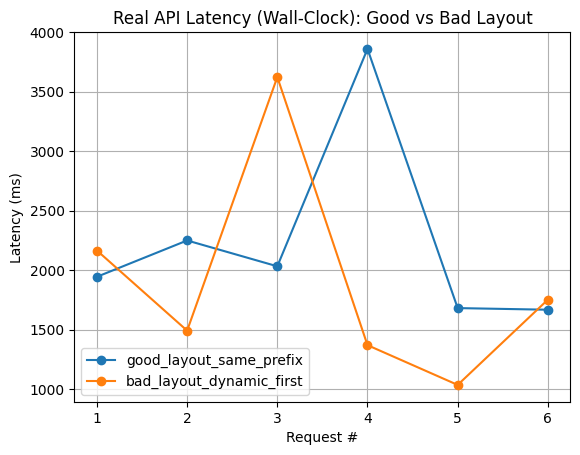

In [31]:
if len(df_api) == 0:
    print("No API results to plot.")
else:
    for scenario_name in df_api["scenario"].unique():
        subset = df_api[df_api["scenario"] == scenario_name]
        plt.plot(subset["request_id"], subset["latency_ms"], marker="o", label=scenario_name)

    plt.title("Real API Latency (Wall-Clock): Good vs Bad Layout")
    plt.xlabel("Request #")
    plt.ylabel("Latency (ms)")
    plt.legend()
    plt.grid(True)
    plt.show()